# DeepLense GSoC 2026 — Test I & VII

**Test I:** Multi-class classification of strong lensing images (`no_sub`, `subhalo`, `vortex`) using fine-tuned EfficientNet-B0.

**Test VII:** Physics-guided variant — same backbone extended with a convergence head that predicts $\kappa(x,y)$ and enforces the lensing Poisson equation $\nabla^2\psi = 2\kappa$ as an auxiliary loss.

Both tests use the same dataset and are evaluated with ROC curves and AUC scores.

## Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os
import shutil

WEIGHTS_DIR = '/content/drive/MyDrive/Colab Notebooks/GoSC26/ML4DQM/'
DRIVE_ZIP_PATH = WEIGHTS_DIR + 'dataset.zip' # Path to zip on Google Drive

LOCAL_ZIP_PATH = '/content/dataset.zip' # Local path for the zip file
LOCAL_EXTRACT_DIR = '/content/dataset_extracted/' # Local directory to extract to

# Copy zip from Drive to local Colab disk if not already copied
if not os.path.exists(LOCAL_ZIP_PATH):
    print(f"Copying {DRIVE_ZIP_PATH} to {LOCAL_ZIP_PATH}...")
    shutil.copy(DRIVE_ZIP_PATH, LOCAL_ZIP_PATH)
    print("Copy complete.")
else:
    print(f"{LOCAL_ZIP_PATH} already exists locally.")

# Extract the dataset locally if not already extracted
if not os.path.exists(LOCAL_EXTRACT_DIR):
    print(f"Extracting {LOCAL_ZIP_PATH} to {LOCAL_EXTRACT_DIR}...")
    with zipfile.ZipFile(LOCAL_ZIP_PATH, 'r') as z:
        z.extractall(LOCAL_EXTRACT_DIR)
    print('Extraction complete.')
else:
    print('Dataset already extracted locally.')

# Update EXTRACT to point to the local directory
EXTRACT = LOCAL_EXTRACT_DIR

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying /content/drive/MyDrive/Colab Notebooks/GoSC26/ML4DQM/dataset.zip to /content/dataset.zip...
Copy complete.
Extracting /content/dataset.zip to /content/dataset_extracted/...
Extraction complete.


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


## Dataset

In [ ]:
# Folder names inside the zip vs. the display names expected by the test spec
CLASS_NAMES   = ['no', 'sphere', 'vort']
CLASS_TO_IDX  = {c: i for i, c in enumerate(CLASS_NAMES)}
DISPLAY_NAMES = {'no': 'no_sub', 'sphere': 'subhalo', 'vort': 'vortex'}

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]


class LensingDataset(Dataset):
    """Loads .npy lensing images from class subdirectories."""
    def __init__(self, root):
        self.samples = []
        for cls, idx in CLASS_TO_IDX.items():
            d = os.path.join(root, cls)
            for f in sorted(os.listdir(d)):
                if f.endswith('.npy'):
                    self.samples.append((os.path.join(d, f), idx))
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = np.load(path).astype(np.float32)
        if img.ndim == 3:
            img = img.squeeze(0)
        # Single channel -> 3-channel for pretrained backbone
        return torch.from_numpy(img).unsqueeze(0).repeat(3, 1, 1), label


class WithTransform(Dataset):
    def __init__(self, ds, tf):
        self.ds, self.tf = ds, tf
    def __len__(self):
        return len(self.ds)
    def __getitem__(self, i):
        img, label = self.ds[i]
        return self.tf(img), label


# Flips and 90-degree rotations are exact symmetries of lensing images
# (no preferred orientation), so they are physics-motivated augmentations.
train_tf = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomApply([T.RandomRotation((90, 90))], p=0.5),
    T.Resize((224, 224)),
    T.Normalize(MEAN, STD),
])
val_tf = T.Compose([T.Resize((224, 224)), T.Normalize(MEAN, STD)])

# Walk the extracted directory to find where train/ and val/ live
# Ensure to start walking from the local extracted directory
DATA_ROOT = LOCAL_EXTRACT_DIR # Start with the base local extraction directory
for root, dirs, files in os.walk(LOCAL_EXTRACT_DIR):
    if '__MACOSX' in root:
        continue
    if 'train' in dirs and 'val' in dirs:
        DATA_ROOT = root
        break
print('DATA_ROOT:', DATA_ROOT)

train_set    = WithTransform(LensingDataset(os.path.join(DATA_ROOT, 'train')), train_tf)
val_set      = WithTransform(LensingDataset(os.path.join(DATA_ROOT, 'val')),   val_tf)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False, num_workers=0)

print(f'Train: {len(train_set)}  Val: {len(val_set)}')
for c, i in CLASS_TO_IDX.items():
    n = sum(1 for _, l in train_set.ds.samples if l == i)
    print(f'  {DISPLAY_NAMES[c]}: {n}')

DATA_ROOT: /content/dataset_extracted/dataset
Train: 30000  Val: 7500
  no_sub: 10000
  subhalo: 10000
  vortex: 10000


---
# Test I — EfficientNet-B0 Classifier

EfficientNet-B0 pretrained on ImageNet, classification head replaced for 3 classes.

Training is two-phase: backbone frozen for 5 epochs (head-only warmup), then full fine-tune with cosine LR decay for 25 epochs.

In [ ]:
class LensingClassifier(nn.Module):
    def __init__(self, num_classes=3, freeze_backbone=False):
        super().__init__()
        base = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.backbone = base.features   # output: (B, 1280, 7, 7) for 224x224
        self.pool     = base.avgpool
        self.dropout  = nn.Dropout(0.3)
        self.head     = nn.Linear(1280, num_classes)
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def unfreeze(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x).flatten(1)
        return self.head(self.dropout(x))


model1 = LensingClassifier(freeze_backbone=True).to(DEVICE)
print('Trainable params:', sum(p.numel() for p in model1.parameters() if p.requires_grad))

Trainable params: 3843


In [ ]:
from tqdm.auto import tqdm

WARMUP_1   = 5
FINETUNE_1 = 25
TOTAL_1    = WARMUP_1 + FINETUNE_1

criterion  = nn.CrossEntropyLoss()
optimizer1 = optim.Adam(filter(lambda p: p.requires_grad, model1.parameters()), lr=1e-3)
scheduler1 = optim.lr_scheduler.CosineAnnealingLR(optimizer1, T_max=WARMUP_1)

hist1 = {'tl': [], 'vl': [], 'ta': [], 'va': []}

for epoch in range(1, TOTAL_1 + 1):
    if epoch == WARMUP_1 + 1:
        print('--- unfreezing backbone ---')
        model1.unfreeze()
        optimizer1 = optim.Adam(model1.parameters(), lr=3e-4)
        scheduler1 = optim.lr_scheduler.CosineAnnealingLR(optimizer1, T_max=FINETUNE_1)

    for phase, loader, train in [('train', train_loader, True), ('val', val_loader, False)]:
        model1.train(train)
        loss_sum, correct, total = 0., 0, 0

        pbar = tqdm(loader, desc=f"{phase.capitalize()} Epoch {epoch}/{TOTAL_1}", leave=False)

        with torch.set_grad_enabled(train):
            for imgs, labels in pbar:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                logits = model1(imgs)
                loss   = criterion(logits, labels)
                if train:
                    optimizer1.zero_grad(); loss.backward(); optimizer1.step()

                loss_sum += loss.item() * len(labels)
                correct  += (logits.argmax(1) == labels).sum().item()
                total    += len(labels)

                pbar.set_postfix({'loss': f'{loss_sum/total:.4f}', 'acc': f'{correct/total:.4f}'})

        key = 't' if phase == 'train' else 'v'
        hist1[key + 'l'].append(loss_sum / total)
        hist1[key + 'a'].append(correct  / total)

    scheduler1.step()
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:2d}/{TOTAL_1}  '
              f'train loss {hist1["tl"][-1]:.4f} acc {hist1["ta"][-1]:.4f}  '
              f'val loss {hist1["vl"][-1]:.4f} acc {hist1["va"][-1]:.4f}')

torch.save(model1.state_dict(), WEIGHTS_DIR + 'lensing_efficientnet_b0.pt')
print('Saved.')

Train Epoch 1/30:   0%|          | 0/938 [00:00<?, ?it/s]

Val Epoch 1/30:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch  1/30  train loss 1.1112 acc 0.3685  val loss 1.0964 acc 0.3653


Train Epoch 2/30:   0%|          | 0/938 [00:00<?, ?it/s]

Val Epoch 2/30:   0%|          | 0/235 [00:00<?, ?it/s]

...

Train Epoch 29/30:   0%|          | 0/938 [00:00<?, ?it/s]

Val Epoch 29/30:   0%|          | 0/235 [00:00<?, ?it/s]

Train Epoch 30/30:   0%|          | 0/938 [00:00<?, ?it/s]

Val Epoch 30/30:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 30/30  train loss 0.0662 acc 0.9776  val loss 0.1186 acc 0.9623
Saved.


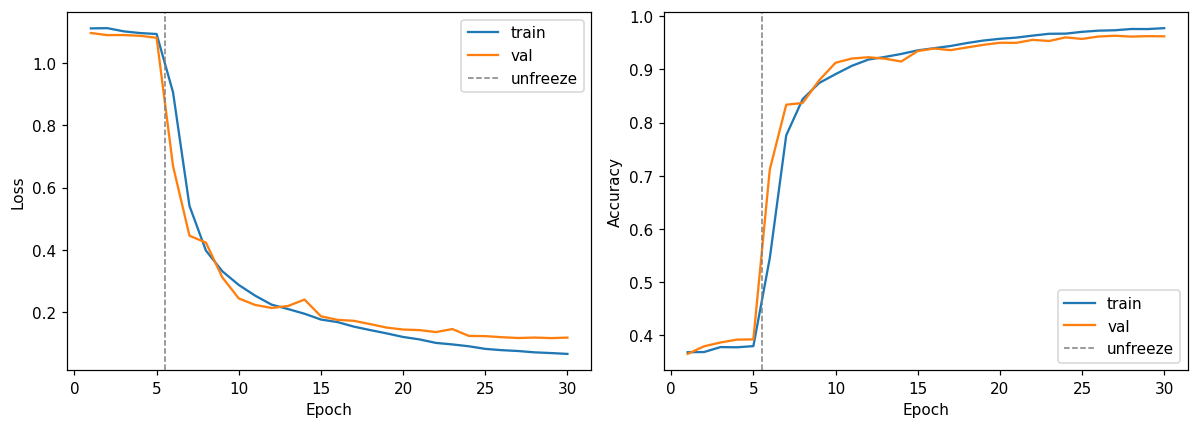

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ep = range(1, TOTAL_1 + 1)
ax1.plot(ep, hist1['tl'], label='train'); ax1.plot(ep, hist1['vl'], label='val')
ax1.axvline(WARMUP_1 + 0.5, color='gray', ls='--', lw=1, label='unfreeze')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()
ax2.plot(ep, hist1['ta'], label='train'); ax2.plot(ep, hist1['va'], label='val')
ax2.axvline(WARMUP_1 + 0.5, color='gray', ls='--', lw=1, label='unfreeze')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend()
plt.tight_layout()
plt.savefig(WEIGHTS_DIR + 'training_curves_t1.png', bbox_inches='tight')
plt.show()

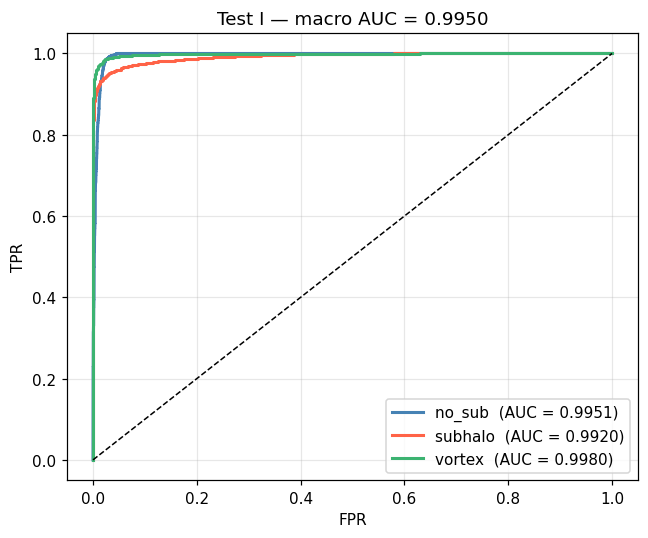

AUC per class:
  no_sub: 0.9951
  subhalo: 0.9920
  vortex: 0.9980
  macro: 0.9950


In [ ]:
model1.eval()
probs1, labels1 = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        probs1.append(torch.softmax(model1(imgs.to(DEVICE)), dim=1).cpu().numpy())
        labels1.append(labels.numpy())
probs1  = np.concatenate(probs1)
labels1 = np.concatenate(labels1)
bins1   = label_binarize(labels1, classes=[0, 1, 2])

colors = ['steelblue', 'tomato', 'mediumseagreen']
aucs1  = {}
fig, ax = plt.subplots(figsize=(6, 5))
for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(bins1[:, i], probs1[:, i])
    a = auc(fpr, tpr); aucs1[cls] = a
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{DISPLAY_NAMES[cls]}  (AUC = {a:.4f})')
macro1 = np.mean(list(aucs1.values()))
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'Test I — macro AUC = {macro1:.4f}')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(WEIGHTS_DIR + 'roc_t1.png', bbox_inches='tight')
plt.show()
print('AUC per class:')
for cls, a in aucs1.items():
    print(f'  {DISPLAY_NAMES[cls]}: {a:.4f}')
print(f'  macro: {macro1:.4f}')

---
# Test VII — Physics-Guided Classifier

We extend the Test I model by incorporating the gravitational lensing equation.

**Physics:** The lensing convergence $\kappa(x,y)$ is the dimensionless projected surface mass density. It determines the deflection of light via the lensing potential $\psi$, which satisfies the Poisson equation:
$$\nabla^2 \psi = 2\kappa$$
The three classes differ in their $\kappa$ distributions: `no_sub` has a smooth elliptical profile, `subhalo` has localized clumps, and `vortex` has a ring-like pattern. Making the network predict $\kappa$ as an intermediate variable and enforcing the Poisson equation gives the classifier direct access to the inferred mass distribution.

**Architecture additions:**
- `kappa_head`: small conv applied to backbone spatial features → 7×7 $\kappa$ map ($\kappa \geq 0$ via Softplus)
- `cls_head`: backbone pool (1280-d) + mean $\kappa$ (1-d) → 3 classes

**Total loss:**
$$\mathcal{L} = \mathcal{L}_{\mathrm{CE}} + \lambda(t)\,\underbrace{\|\nabla^2\psi - 2\kappa\|^2}_{\mathcal{L}_{\mathrm{Poisson}}} + 0.05\,\underbrace{(-\mathrm{Var}(\kappa))}_{\mathcal{L}_{\mathrm{var}}}$$

The variance term prevents $\kappa$ from collapsing to zero (which would trivially satisfy Poisson but carry no information). $\lambda$ ramps from 0 to 0.5 over the warmup phase.

In [ ]:
def laplacian2d(u):
    """Discrete Laplacian via central finite differences."""
    kernel = torch.tensor([[0., 1., 0.],
                            [1.,-4., 1.],
                            [0., 1., 0.]], device=u.device).view(1, 1, 3, 3)
    return F.conv2d(F.pad(u, (1,1,1,1), mode='replicate'), kernel)


class PhysicsLensingClassifier(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        base = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.backbone   = base.features
        self.pool       = base.avgpool
        self.dropout    = nn.Dropout(0.3)
        # Convergence head: 1280 -> 64 -> 1 spatial map
        self.kappa_head = nn.Sequential(
            nn.Conv2d(1280, 64, kernel_size=1), nn.ReLU(),
            nn.Conv2d(64,    1, kernel_size=1), nn.Softplus()  # kappa >= 0
        )
        # Classification head: pooled features + mean kappa
        self.cls_head = nn.Linear(1281, num_classes)

    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = True

    def forward(self, x):
        feats    = self.backbone(x)                              # (B, 1280, 7, 7)
        kappa    = self.kappa_head(feats)                        # (B, 1, 7, 7)
        pooled   = self.pool(feats).flatten(1)                   # (B, 1280)
        combined = torch.cat([pooled, kappa.mean(dim=[2,3])], 1) # (B, 1281)
        return self.cls_head(self.dropout(combined)), kappa


def physics_loss(kappa, lambda_p):
    """Poisson residual + variance regularizer."""
    # Approximate psi by smoothing kappa, then check nabla^2(psi) = 2*kappa
    smooth = torch.ones(1, 1, 3, 3, device=kappa.device) / 9.
    psi    = F.conv2d(F.pad(kappa, (1,1,1,1), mode='replicate'), smooth)
    l_pois = (laplacian2d(psi) - 2. * kappa).pow(2).mean()
    # Penalize flat kappa maps to prevent trivial collapse
    l_var  = -kappa.var(dim=[2, 3]).mean()
    return lambda_p * l_pois + 0.05 * l_var


model7 = PhysicsLensingClassifier().to(DEVICE)

# Initialize backbone from Test I weights
state1 = torch.load(WEIGHTS_DIR + 'lensing_efficientnet_b0.pt', map_location=DEVICE)
backbone_state = {k: v for k, v in state1.items() if k.startswith('backbone')}
model7.load_state_dict(backbone_state, strict=False)
print('Backbone loaded from Test I.')

Backbone loaded from Test I.


In [ ]:
WARMUP_7   = 5
FINETUNE_7 = 20
TOTAL_7    = WARMUP_7 + FINETUNE_7
LAMBDA_MAX = 0.5

# Phase 1: backbone frozen, only new heads train
model7.freeze_backbone()
optimizer7 = optim.Adam(filter(lambda p: p.requires_grad, model7.parameters()), lr=5e-4)
scheduler7 = optim.lr_scheduler.CosineAnnealingLR(optimizer7, T_max=WARMUP_7)

hist7 = {'tl': [], 'vl': [], 'ta': [], 'va': [], 'tp': []}

for epoch in range(1, TOTAL_7 + 1):
    if epoch == WARMUP_7 + 1:
        print('--- unfreezing backbone ---')
        model7.unfreeze_backbone()
        optimizer7 = optim.Adam(model7.parameters(), lr=5e-5)
        scheduler7 = optim.lr_scheduler.CosineAnnealingLR(optimizer7, T_max=FINETUNE_7)

    # Lambda ramps linearly to LAMBDA_MAX during warmup, then stays fixed
    lam = LAMBDA_MAX * min(epoch / WARMUP_7, 1.0)

    for phase, loader, train in [('train', train_loader, True), ('val', val_loader, False)]:
        model7.train(train)
        ce_sum, phys_sum, correct, total = 0., 0., 0, 0
        with torch.set_grad_enabled(train):
            for imgs, labels in loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                logits, kappa = model7(imgs)
                loss_ce   = criterion(logits, labels)
                loss_phys = physics_loss(kappa, lam)
                loss      = loss_ce + loss_phys
                if train:
                    optimizer7.zero_grad(); loss.backward(); optimizer7.step()
                ce_sum   += loss_ce.item()   * len(labels)
                phys_sum += loss_phys.item() * len(labels)
                correct  += (logits.argmax(1) == labels).sum().item()
                total    += len(labels)
        key = 't' if phase == 'train' else 'v'
        hist7[key + 'l'].append(ce_sum  / total)
        hist7[key + 'a'].append(correct / total)
        if phase == 'train':
            hist7['tp'].append(phys_sum / total)

    scheduler7.step()
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:2d}/{TOTAL_7}  '
              f'CE {hist7["tl"][-1]:.4f}  '
              f'Phys {hist7["tp"][-1]:.4f}  '
              f'λ={lam:.2f}  '
              f'train acc {hist7["ta"][-1]:.4f}  '
              f'val acc {hist7["va"][-1]:.4f}')

torch.save(model7.state_dict(), WEIGHTS_DIR + 'lensing_physics_guided.pt')
print('Saved.')

Epoch  1/25  CE 0.0894  Phys 0.0025  λ=0.10  train acc 0.9733  val acc 0.9621
Epoch  5/25  CE 0.0673  Phys 0.0000  λ=0.50  train acc 0.9763  val acc 0.9625
--- unfreezing backbone ---
Epoch 10/25  CE 0.0698  Phys 0.0000  λ=0.50  train acc 0.9760  val acc 0.9609
Epoch 15/25  CE 0.0578  Phys 0.0000  λ=0.50  train acc 0.9805  val acc 0.9613
Epoch 20/25  CE 0.0481  Phys 0.0000  λ=0.50  train acc 0.9834  val acc 0.9636
Epoch 25/25  CE 0.0483  Phys 0.0000  λ=0.50  train acc 0.9834  val acc 0.9649
Saved.


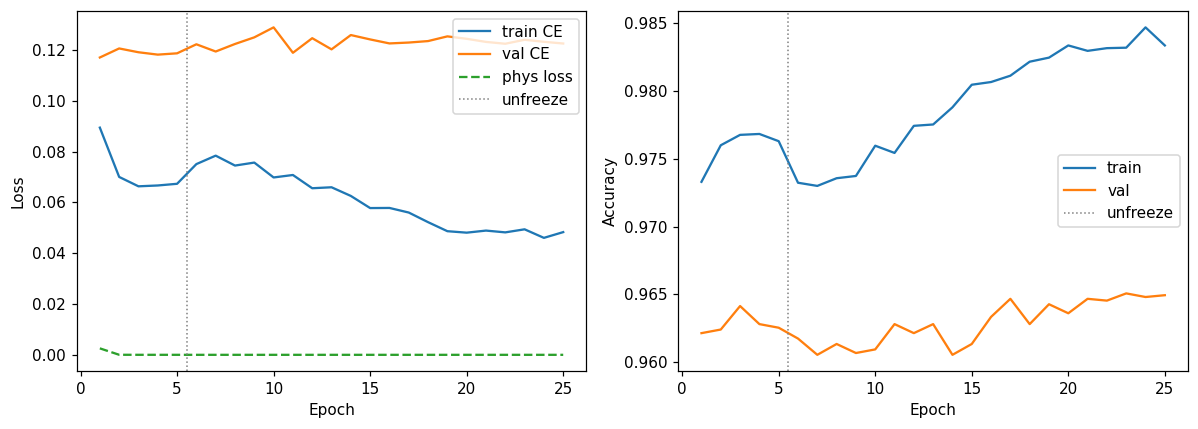

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ep = range(1, TOTAL_7 + 1)
ax1.plot(ep, hist7['tl'], label='train CE')
ax1.plot(ep, hist7['vl'], label='val CE')
ax1.plot(ep, hist7['tp'], label='phys loss', ls='--')
ax1.axvline(WARMUP_7 + 0.5, color='gray', ls=':', lw=1, label='unfreeze')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()
ax2.plot(ep, hist7['ta'], label='train')
ax2.plot(ep, hist7['va'], label='val')
ax2.axvline(WARMUP_7 + 0.5, color='gray', ls=':', lw=1, label='unfreeze')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend()
plt.tight_layout()
plt.savefig(WEIGHTS_DIR + 'training_curves_t7.png', bbox_inches='tight')
plt.show()

## ROC comparison: Test I vs Test VII

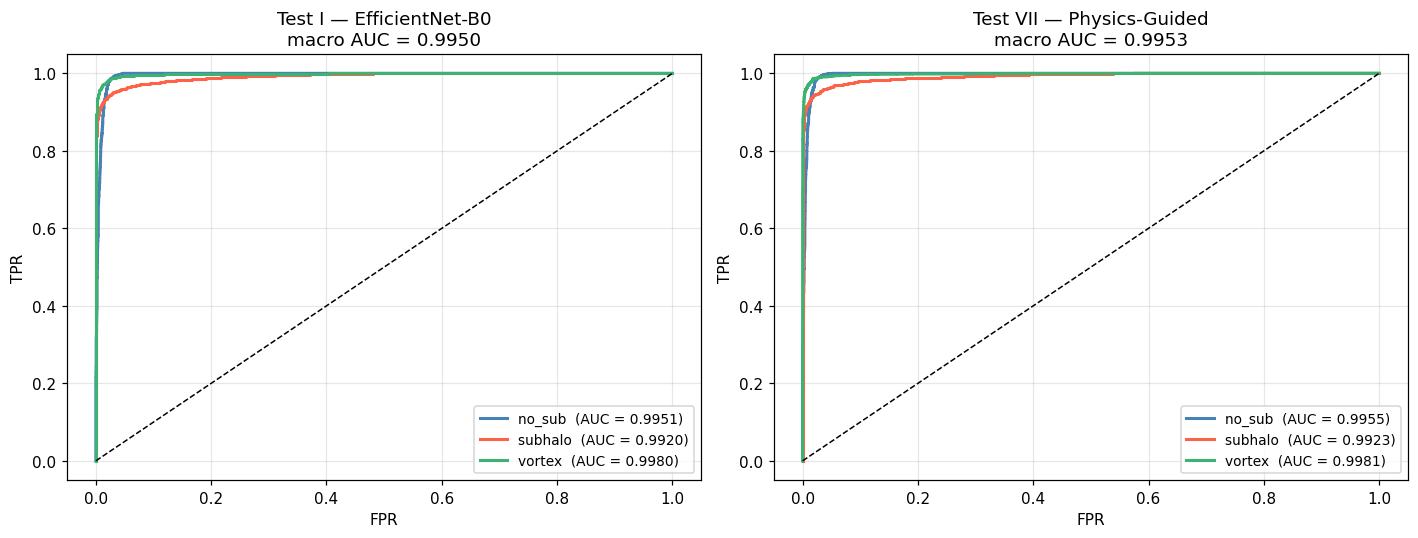


class         Test I  Test VII
no_sub        0.9951    0.9955
subhalo       0.9920    0.9923
vortex        0.9980    0.9981
macro         0.9950    0.9953


In [ ]:
model7.eval()
probs7, labels7 = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        logits, _ = model7(imgs.to(DEVICE))
        probs7.append(torch.softmax(logits, dim=1).cpu().numpy())
        labels7.append(labels.numpy())
probs7  = np.concatenate(probs7)
labels7 = np.concatenate(labels7)
bins7   = label_binarize(labels7, classes=[0, 1, 2])

aucs7 = {}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, probs, bins, aucs_d, title in [
    (axes[0], probs1, bins1, aucs1, 'Test I — EfficientNet-B0'),
    (axes[1], probs7, bins7, aucs7, 'Test VII — Physics-Guided'),
]:
    for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
        fpr, tpr, _ = roc_curve(bins[:, i], probs[:, i])
        a = auc(fpr, tpr); aucs_d[cls] = a
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{DISPLAY_NAMES[cls]}  (AUC = {a:.4f})')
    macro = np.mean(list(aucs_d.values()))
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'{title}\nmacro AUC = {macro:.4f}')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(WEIGHTS_DIR + 'roc_comparison.png', bbox_inches='tight')
plt.show()

m1 = np.mean(list(aucs1.values()))
m7 = np.mean(list(aucs7.values()))
print(f'\n{"class":10s}  {"Test I":>8s}  {"Test VII":>8s}')
for cls in CLASS_NAMES:
    print(f'{DISPLAY_NAMES[cls]:10s}  {aucs1[cls]:8.4f}  {aucs7[cls]:8.4f}')
print(f'{"macro":10s}  {m1:8.4f}  {m7:8.4f}')

## Convergence map visualization

Row 1: input image. Row 2: predicted $\kappa$ map (7×7 from backbone). Row 3: $\kappa$ overlaid on image.

We expect `subhalo` to show localized bright spots and `vortex` to show a ring pattern — qualitative confirmation that the physics head is learning meaningful structure.

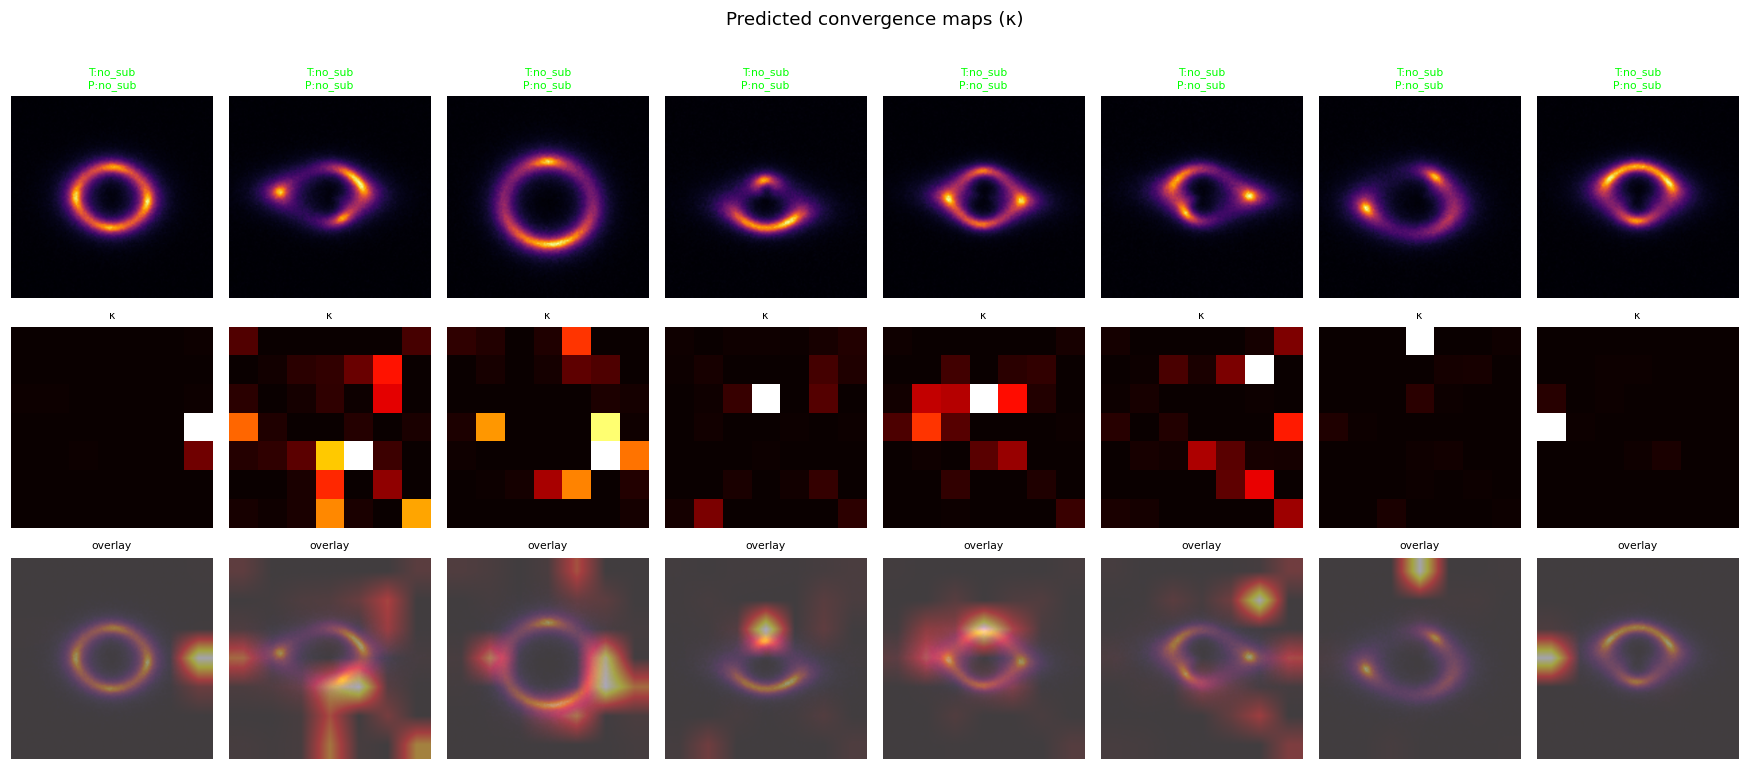

In [ ]:
model7.eval()
imgs, labels = next(iter(val_loader))
with torch.no_grad():
    logits, kappa_maps = model7(imgs.to(DEVICE))
    preds = logits.argmax(1).cpu()
kappa_maps = kappa_maps.cpu().squeeze(1)

fig, axes = plt.subplots(3, 8, figsize=(16, 7))
for i in range(8):
    img = imgs[i, 0].numpy() * STD[0] + MEAN[0]
    t   = DISPLAY_NAMES[CLASS_NAMES[labels[i].item()]]
    p   = DISPLAY_NAMES[CLASS_NAMES[preds[i].item()]]

    axes[0, i].imshow(img, cmap='inferno', origin='lower')
    axes[0, i].set_title(f'T:{t}\nP:{p}', fontsize=7,
                          color='lime' if t == p else 'red')
    axes[0, i].axis('off')

    axes[1, i].imshow(kappa_maps[i].numpy(), cmap='hot', origin='lower')
    axes[1, i].set_title('κ', fontsize=7); axes[1, i].axis('off')

    km_up = F.interpolate(kappa_maps[i:i+1].unsqueeze(0),
                          size=img.shape, mode='bilinear',
                          align_corners=False).squeeze().numpy()
    axes[2, i].imshow(img,   cmap='inferno', origin='lower', alpha=0.6)
    axes[2, i].imshow(km_up, cmap='hot',     origin='lower', alpha=0.4)
    axes[2, i].set_title('overlay', fontsize=7); axes[2, i].axis('off')

axes[0,0].set_ylabel('input',   fontsize=8)
axes[1,0].set_ylabel('κ',       fontsize=8)
axes[2,0].set_ylabel('overlay', fontsize=8)
plt.suptitle('Predicted convergence maps (κ)', y=1.01)
plt.tight_layout()
plt.savefig(WEIGHTS_DIR + 'kappa_maps.png', bbox_inches='tight')
plt.show()

# Additional checks

In [ ]:
# Quick debug
print(f'probs1: len={len(probs1)}, type[0]={type(probs1[0])}, shape[0]={np.asarray(probs1[0]).shape}')
print(f'probs7: len={len(probs7)}, type[0]={type(probs7[0])}, shape[0]={np.asarray(probs7[0]).shape}')
print(f'labels1: len={len(labels1)}, type[0]={type(labels1[0])}, shape[0]={np.asarray(labels1[0]).shape}')
print(f'labels7: len={len(labels7)}, type[0]={type(labels7[0])}, shape[0]={np.asarray(labels7[0]).shape}')

probs1: len=7500, type[0]=<class 'numpy.ndarray'>, shape[0]=(3,)
probs7: len=7500, type[0]=<class 'numpy.ndarray'>, shape[0]=(3,)
labels1: len=7500, type[0]=<class 'numpy.int64'>, shape[0]=()
labels7: len=7500, type[0]=<class 'numpy.int64'>, shape[0]=()


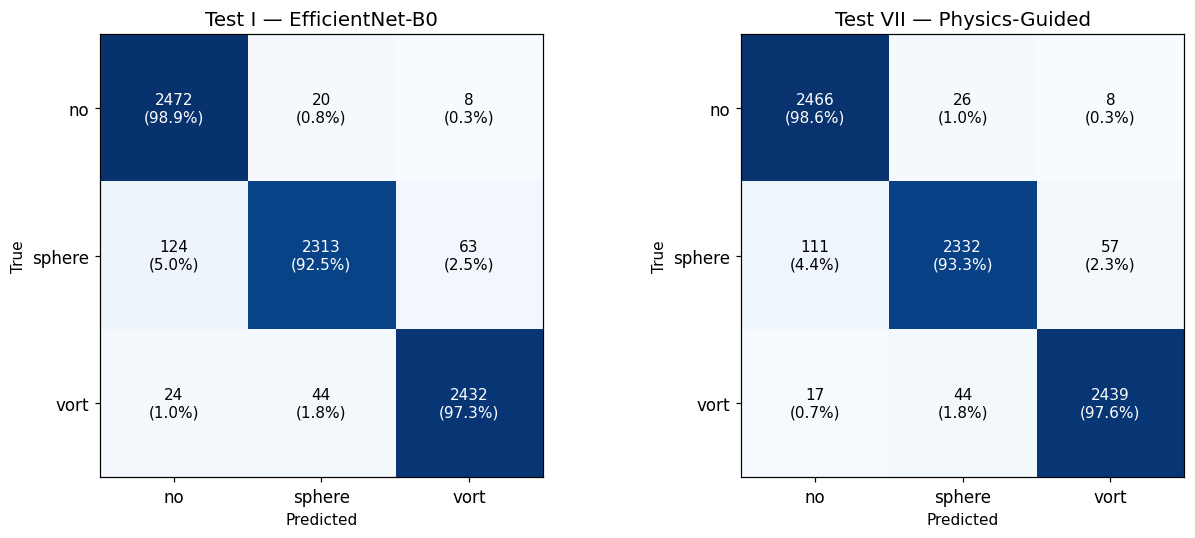


Test I Classification Report:
              precision    recall  f1-score   support

          no     0.9435    0.9888    0.9656      2500
      sphere     0.9731    0.9252    0.9485      2500
        vort     0.9716    0.9728    0.9722      2500

    accuracy                         0.9623      7500
   macro avg     0.9627    0.9623    0.9621      7500
weighted avg     0.9627    0.9623    0.9621      7500


Test VII Classification Report:
              precision    recall  f1-score   support

          no     0.9507    0.9864    0.9682      2500
      sphere     0.9709    0.9328    0.9514      2500
        vort     0.9740    0.9756    0.9748      2500

    accuracy                         0.9649      7500
   macro avg     0.9652    0.9649    0.9648      7500
weighted avg     0.9652    0.9649    0.9648      7500



In [37]:

from sklearn.metrics import confusion_matrix, classification_report
import itertools

p1 = np.vstack(probs1)          # (7500, 3)
p7 = np.vstack(probs7)          # (7500, 3)
y1 = np.array(labels1)          # (7500,)
y7 = np.array(labels7)          # (7500,)

preds1 = p1.argmax(1)
preds7 = p7.argmax(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, y_true, title in [(ax1, preds1, y1, 'Test I — EfficientNet-B0'),
                                  (ax2, preds7, y7, 'Test VII — Physics-Guided')]:
    cm = confusion_matrix(y_true, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ax.imshow(cm_pct, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title, fontsize=13)
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(CLASS_NAMES, fontsize=11)
    ax.set_yticklabels(CLASS_NAMES, fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i, j in itertools.product(range(3), range(3)):
        ax.text(j, i, f'{cm[i,j]}\n({cm_pct[i,j]:.1%})',
                ha='center', va='center',
                color='white' if cm_pct[i,j] > 0.5 else 'black', fontsize=10)
plt.tight_layout()
plt.savefig(WEIGHTS_DIR + 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

for name, preds, y in [('Test I', preds1, y1), ('Test VII', preds7, y7)]:
    print(f'\n{name} Classification Report:')
    print(classification_report(y, preds, target_names=CLASS_NAMES, digits=4))


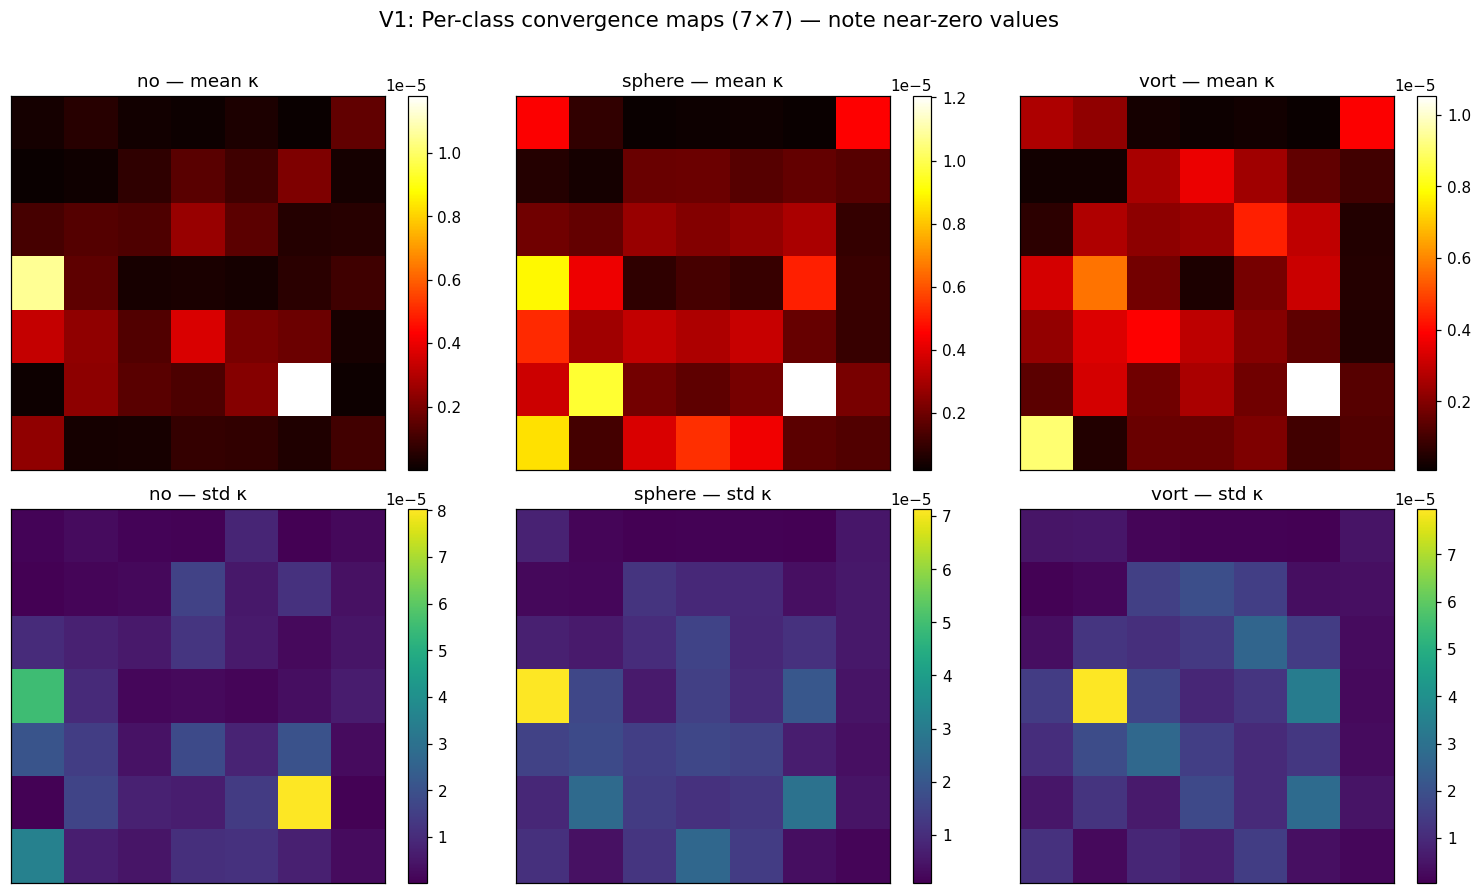

      no  mean(κ)=0.000001  std(κ)=0.000017  max(κ)=0.003490  spatial_var=0.00000000
  sphere  mean(κ)=0.000003  std(κ)=0.000015  max(κ)=0.003127  spatial_var=0.00000000
    vort  mean(κ)=0.000002  std(κ)=0.000017  max(κ)=0.003862  spatial_var=0.00000000

⚠ V1 κ maps are near-zero: the Poisson constraint is trivially satisfied.
  V2 below addresses this with a spectral solver + gradient clipping.


In [38]:

model7.eval()
kappa_by_class = {c: [] for c in range(3)}
with torch.no_grad():
    for imgs, labs in val_loader:
        _, kappa_maps = model7(imgs.to(DEVICE))
        for k_map, lab in zip(kappa_maps.cpu(), labs):
            kappa_by_class[lab.item()].append(k_map.squeeze().numpy())

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for c in range(3):
    stack = np.stack(kappa_by_class[c])
    mean_k = stack.mean(axis=0)
    std_k  = stack.std(axis=0)
    im1 = axes[0, c].imshow(mean_k, cmap='hot', interpolation='nearest')
    axes[0, c].set_title(f'{CLASS_NAMES[c]} — mean κ', fontsize=12)
    plt.colorbar(im1, ax=axes[0, c], fraction=0.046)
    im2 = axes[1, c].imshow(std_k, cmap='viridis', interpolation='nearest')
    axes[1, c].set_title(f'{CLASS_NAMES[c]} — std κ', fontsize=12)
    plt.colorbar(im2, ax=axes[1, c], fraction=0.046)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('V1: Per-class convergence maps (7×7) — note near-zero values', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(WEIGHTS_DIR + 'kappa_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

for c in range(3):
    stack = np.stack(kappa_by_class[c])
    print(f'{CLASS_NAMES[c]:>8s}  mean(κ)={stack.mean():.6f}  std(κ)={stack.std():.6f}  '
          f'max(κ)={stack.max():.6f}  spatial_var={stack.var(axis=(1,2)).mean():.8f}')

print('\n⚠ V1 κ maps are near-zero: the Poisson constraint is trivially satisfied.')
print('  V2 below addresses this with a spectral solver + gradient clipping.')

In [39]:

class PhysicsLensingV2(nn.Module):
    """
    Key fixes over V1:
    1. Spectral Poisson solver: ψ computed via FFT, residual via finite-diff
       → non-trivial physics gradient.
    2. 28×28 κ maps via learned upsampling.
    3. Deflection |∇ψ| stats fed to classifier.
    4. Careful normalization to prevent NaN:
       - LayerNorm after kappa head
       - Clamp κ values
    """
    def __init__(self, num_classes=3, kappa_res=28):
        super().__init__()
        self.kappa_res = kappa_res
        base = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.backbone = base.features
        self.pool     = base.avgpool
        self.dropout  = nn.Dropout(0.3)

        # Higher-res κ head: 7→28 upsample, then conv stack
        self.kappa_head = nn.Sequential(
            nn.Upsample(size=kappa_res, mode='bilinear', align_corners=False),
            nn.Conv2d(1280, 128, 3, padding=1), nn.GELU(),
            nn.BatchNorm2d(128),
            nn.Conv2d(128,   64, 3, padding=1), nn.GELU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(64,     1, 1),             nn.Softplus(),
        )

        # Spectral Laplacian eigenvalues (fixed buffer)
        freqs = torch.fft.fftfreq(kappa_res)
        kx, ky = torch.meshgrid(freqs, freqs, indexing='ij')
        lap_eigenvals = -(2 * np.pi)**2 * (kx**2 + ky**2)
        lap_eigenvals[0, 0] = 1.0  # DC: avoid div-by-zero
        self.register_buffer('lap_eigenvals', lap_eigenvals)

        # cls: pooled backbone (1280) + kappa stats (3) + deflection stats (2)
        self.cls_head = nn.Linear(1280 + 5, num_classes)

    def solve_poisson(self, kappa):
        """Solve ∇²ψ = 2κ spectrally. Returns ψ, αx, αy."""
        kappa_hat = torch.fft.fft2(kappa)
        psi_hat   = 2.0 * kappa_hat / self.lap_eigenvals.unsqueeze(0).unsqueeze(0)
        psi       = torch.fft.ifft2(psi_hat).real
        # Clamp to prevent extreme values
        psi = psi.clamp(-10, 10)
        alpha_x = (torch.roll(psi, -1, dims=-1) - torch.roll(psi, 1, dims=-1)) / 2.0
        alpha_y = (torch.roll(psi, -1, dims=-2) - torch.roll(psi, 1, dims=-2)) / 2.0
        return psi, alpha_x, alpha_y

    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False
    def unfreeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = True

    def forward(self, x):
        feats  = self.backbone(x)                              # (B,1280,7,7)
        kappa  = self.kappa_head(feats)                        # (B,1,28,28)
        kappa  = kappa.clamp(0, 5.0)                           # prevent runaway
        psi, ax, ay = self.solve_poisson(kappa)
        defl_mag = (ax**2 + ay**2).sqrt()

        pooled = self.pool(feats).flatten(1)                   # (B,1280)
        k_stats = torch.stack([kappa.mean(dim=[2,3]).squeeze(1),
                               kappa.std(dim=[2,3]).squeeze(1),
                               kappa.amax(dim=(2,3)).squeeze(1)], dim=1)
        d_stats = torch.stack([defl_mag.mean(dim=[2,3]).squeeze(1),
                               defl_mag.std(dim=[2,3]).squeeze(1)], dim=1)
        combined = torch.cat([pooled, k_stats, d_stats], dim=1)
        logits = self.cls_head(self.dropout(combined))
        return logits, kappa, psi


def laplacian2d(u):
    """Discrete Laplacian via central finite differences."""
    kernel = torch.tensor([[0., 1., 0.],
                            [1.,-4., 1.],
                            [0., 1., 0.]], device=u.device).view(1, 1, 3, 3)
    return F.conv2d(F.pad(u, (1,1,1,1), mode='replicate'), kernel)


def physics_loss_v2(kappa, psi, lambda_p):
    """
    Poisson consistency + structure regularizers.
    Spectral solve gives exact ψ, but finite-diff Laplacian ≠ spectral Laplacian
    → non-trivial residual that provides real gradient signal.
    """
    lap_psi = laplacian2d(psi)
    residual = (lap_psi - 2.0 * kappa)
    # Clamp residual to prevent explosion
    residual = residual.clamp(-5, 5)
    l_poisson = residual.pow(2).mean()

    # Encourage non-trivial κ (prevent collapse to zero)
    l_var = -kappa.var(dim=[2, 3]).mean()

    # Smoothness prior on κ
    dx = (kappa[:,:,:,1:] - kappa[:,:,:,:-1]).pow(2).mean()
    dy = (kappa[:,:,1:,:] - kappa[:,:,:-1,:]).pow(2).mean()
    l_smooth = 0.01 * (dx + dy)

    return lambda_p * l_poisson + 0.05 * l_var + l_smooth

In [40]:

model_v2 = PhysicsLensingV2().to(DEVICE)

# Load backbone from Test I
state1 = torch.load(WEIGHTS_DIR + 'lensing_efficientnet_b0.pt', map_location=DEVICE)
backbone_state = {k: v for k, v in state1.items() if k.startswith('backbone')}
model_v2.load_state_dict(backbone_state, strict=False)
model_v2.freeze_backbone()
print(f'V2 trainable params (frozen): {sum(p.numel() for p in model_v2.parameters() if p.requires_grad):,}')

WARMUP_V2   = 5
FINETUNE_V2 = 20
TOTAL_V2    = WARMUP_V2 + FINETUNE_V2
LAMBDA_MAX  = 0.1           # ← lower than before to prevent blowup
MAX_GRAD_NORM = 1.0         # gradient clipping

opt_v2 = optim.AdamW(filter(lambda p: p.requires_grad, model_v2.parameters()),
                      lr=5e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

hist_v2 = {'tl':[], 'vl':[], 'ta':[], 'va':[], 'pl':[]}
best_va = 0.0

for epoch in range(1, TOTAL_V2 + 1):
    if epoch == WARMUP_V2 + 1:
        print('--- unfreezing backbone ---')
        model_v2.unfreeze_backbone()
        # Much lower LR for backbone fine-tuning
        opt_v2 = optim.AdamW([
            {'params': model_v2.backbone.parameters(), 'lr': 1e-5},
            {'params': model_v2.kappa_head.parameters(), 'lr': 3e-4},
            {'params': model_v2.cls_head.parameters(), 'lr': 3e-4},
        ], weight_decay=1e-4)
        sched_v2 = optim.lr_scheduler.CosineAnnealingLR(opt_v2, FINETUNE_V2, eta_min=1e-6)

    lam = min(LAMBDA_MAX, LAMBDA_MAX * epoch / WARMUP_V2)

    # ---- Train ----
    model_v2.train()
    tloss, ploss, correct, total = 0, 0, 0, 0
    for imgs, labels in tqdm(train_loader, desc=f'Train V2 {epoch}/{TOTAL_V2}', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits, kappa, psi = model_v2(imgs)

        # NaN guard: skip batch if model output is NaN
        if torch.isnan(logits).any():
            print(f'  ⚠ NaN detected at epoch {epoch}, skipping batch')
            opt_v2.zero_grad()
            continue

        loss_ce = criterion(logits, labels)
        loss_ph = physics_loss_v2(kappa, psi, lam)
        loss = loss_ce + loss_ph

        opt_v2.zero_grad()
        loss.backward()
        # Gradient clipping — the key fix for the NaN explosion
        torch.nn.utils.clip_grad_norm_(model_v2.parameters(), MAX_GRAD_NORM)
        opt_v2.step()

        tloss += loss_ce.item() * imgs.size(0)
        ploss += loss_ph.item() * imgs.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += imgs.size(0)

    if epoch > WARMUP_V2:
        sched_v2.step()

    # ---- Val ----
    model_v2.eval()
    vloss, vcorrect, vtotal = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f'Val V2 {epoch}/{TOTAL_V2}', leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits, _, _ = model_v2(imgs)
            if torch.isnan(logits).any():
                continue
            vloss += criterion(logits, labels).item() * imgs.size(0)
            vcorrect += (logits.argmax(1) == labels).sum().item()
            vtotal += imgs.size(0)

    ta = correct / max(total, 1)
    va = vcorrect / max(vtotal, 1)
    tl = tloss / max(total, 1)
    vl = vloss / max(vtotal, 1)
    pl_avg = ploss / max(total, 1)
    hist_v2['tl'].append(tl); hist_v2['vl'].append(vl)
    hist_v2['ta'].append(ta); hist_v2['va'].append(va)
    hist_v2['pl'].append(pl_avg)

    if va > best_va:
        best_va = va
        torch.save(model_v2.state_dict(), WEIGHTS_DIR + 'lensing_physics_v2_best.pt')

    if epoch % 5 == 1 or epoch == TOTAL_V2:
        print(f'Epoch {epoch:2d}/{TOTAL_V2}  CE {tl:.4f}  Phys {pl_avg:.4f}  '
              f'λ={lam:.2f}  train acc {ta:.4f}  val acc {va:.4f}')

# Reload best checkpoint
model_v2.load_state_dict(torch.load(WEIGHTS_DIR + 'lensing_physics_v2_best.pt', map_location=DEVICE))
print(f'Loaded best V2 (val acc = {best_va:.4f}).')



V2 trainable params (frozen): 1,552,787


Train V2 1/25:   0%|          | 0/938 [00:00<?, ?it/s]

Val V2 1/25:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch  1/25  CE 0.0798  Phys 0.0053  λ=0.02  train acc 0.9752  val acc 0.9624


Train V2 2/25:   0%|          | 0/938 [00:00<?, ?it/s]

...

Train V2 24/25:   0%|          | 0/938 [00:00<?, ?it/s]

Val V2 24/25:   0%|          | 0/235 [00:00<?, ?it/s]

Train V2 25/25:   0%|          | 0/938 [00:00<?, ?it/s]

Val V2 25/25:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 25/25  CE 0.0662  Phys -0.0040  λ=0.10  train acc 0.9794  val acc 0.9625
Loaded best V2 (val acc = 0.9636).


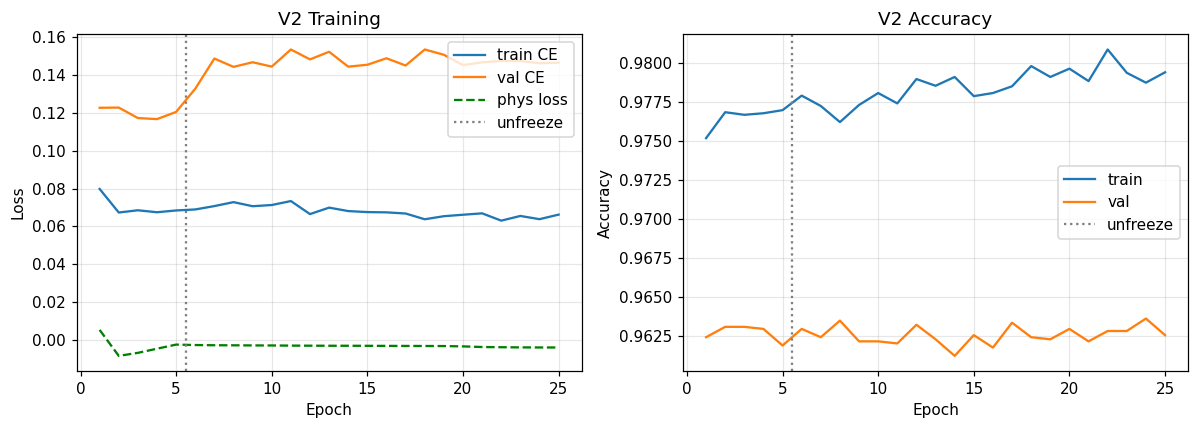

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ep = range(1, TOTAL_V2 + 1)
ax1.plot(ep, hist_v2['tl'], label='train CE')
ax1.plot(ep, hist_v2['vl'], label='val CE')
ax1.plot(ep, hist_v2['pl'], label='phys loss', ls='--', color='green')
ax1.axvline(WARMUP_V2 + 0.5, ls=':', color='grey', label='unfreeze')
ax1.set(xlabel='Epoch', ylabel='Loss', title='V2 Training')
ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(ep, hist_v2['ta'], label='train')
ax2.plot(ep, hist_v2['va'], label='val')
ax2.axvline(WARMUP_V2 + 0.5, ls=':', color='grey', label='unfreeze')
ax2.set(xlabel='Epoch', ylabel='Accuracy', title='V2 Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(WEIGHTS_DIR + 'v2_training.png', dpi=150, bbox_inches='tight')
plt.show()

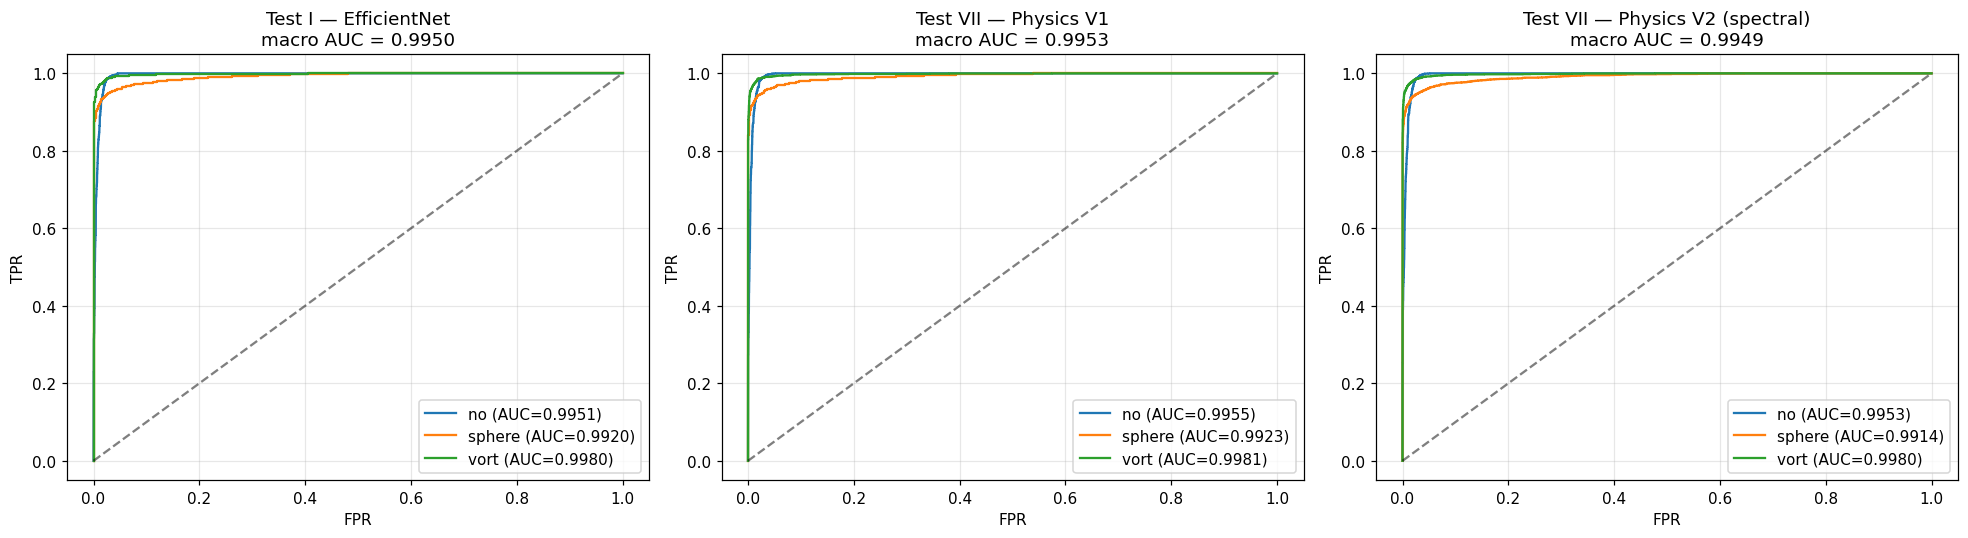


Model                                     no   sphere     vort    macro
-----------------------------------------------------------------------
Test I — EfficientNet                 0.9951   0.9920   0.9980   0.9950
Test VII — Physics V1                 0.9955   0.9923   0.9981   0.9953
Test VII — Physics V2 (spectral)      0.9953   0.9914   0.9980   0.9949


In [42]:

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

model_v2.eval()
probs_v2, labels_v2 = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        logits, _, _ = model_v2(imgs.to(DEVICE))
        probs_v2.append(torch.softmax(logits, 1).cpu().numpy())
        labels_v2.append(labels.numpy())

pv2 = np.concatenate(probs_v2)
yv2 = np.concatenate(labels_v2)

# Sanity check for NaN
if np.isnan(pv2).any():
    print('⚠ V2 probs contain NaN — skipping V2 in ROC plot.')
    print('  Showing Test I vs VII only.')
    all_models = [('Test I — EfficientNet', p1, y1),
                  ('Test VII — Physics V1', p7, y7)]
else:
    all_models = [('Test I — EfficientNet', p1, y1),
                  ('Test VII — Physics V1', p7, y7),
                  ('Test VII — Physics V2 (spectral)', pv2, yv2)]

fig, axes = plt.subplots(1, len(all_models), figsize=(6 * len(all_models), 5))
if len(all_models) == 2:
    axes = list(axes)

auc_table = []
for ax, (name, p, y) in zip(axes, all_models):
    y_bin = label_binarize(y.astype(int), classes=[0,1,2])
    row = {'model': name}
    for c, cn in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_bin[:, c], p[:, c])
        auc_val = roc_auc_score(y_bin[:, c], p[:, c])
        ax.plot(fpr, tpr, label=f'{cn} (AUC={auc_val:.4f})')
        row[cn] = auc_val
    row['macro'] = roc_auc_score(y_bin, p, average='macro', multi_class='ovr')
    auc_table.append(row)
    ax.plot([0,1],[0,1],'k--', alpha=0.5)
    ax.set(xlabel='FPR', ylabel='TPR', title=f'{name}\nmacro AUC = {row["macro"]:.4f}')
    ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(WEIGHTS_DIR + 'roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

header = f'{"Model":<35s}' + ''.join(f' {cn:>8s}' for cn in CLASS_NAMES) + f' {"macro":>8s}'
print(f'\n{header}')
print('-' * len(header))
for row in auc_table:
    vals = ''.join(f' {row[cn]:>8.4f}' for cn in CLASS_NAMES)
    print(f'{row["model"]:<35s}{vals} {row["macro"]:>8.4f}')


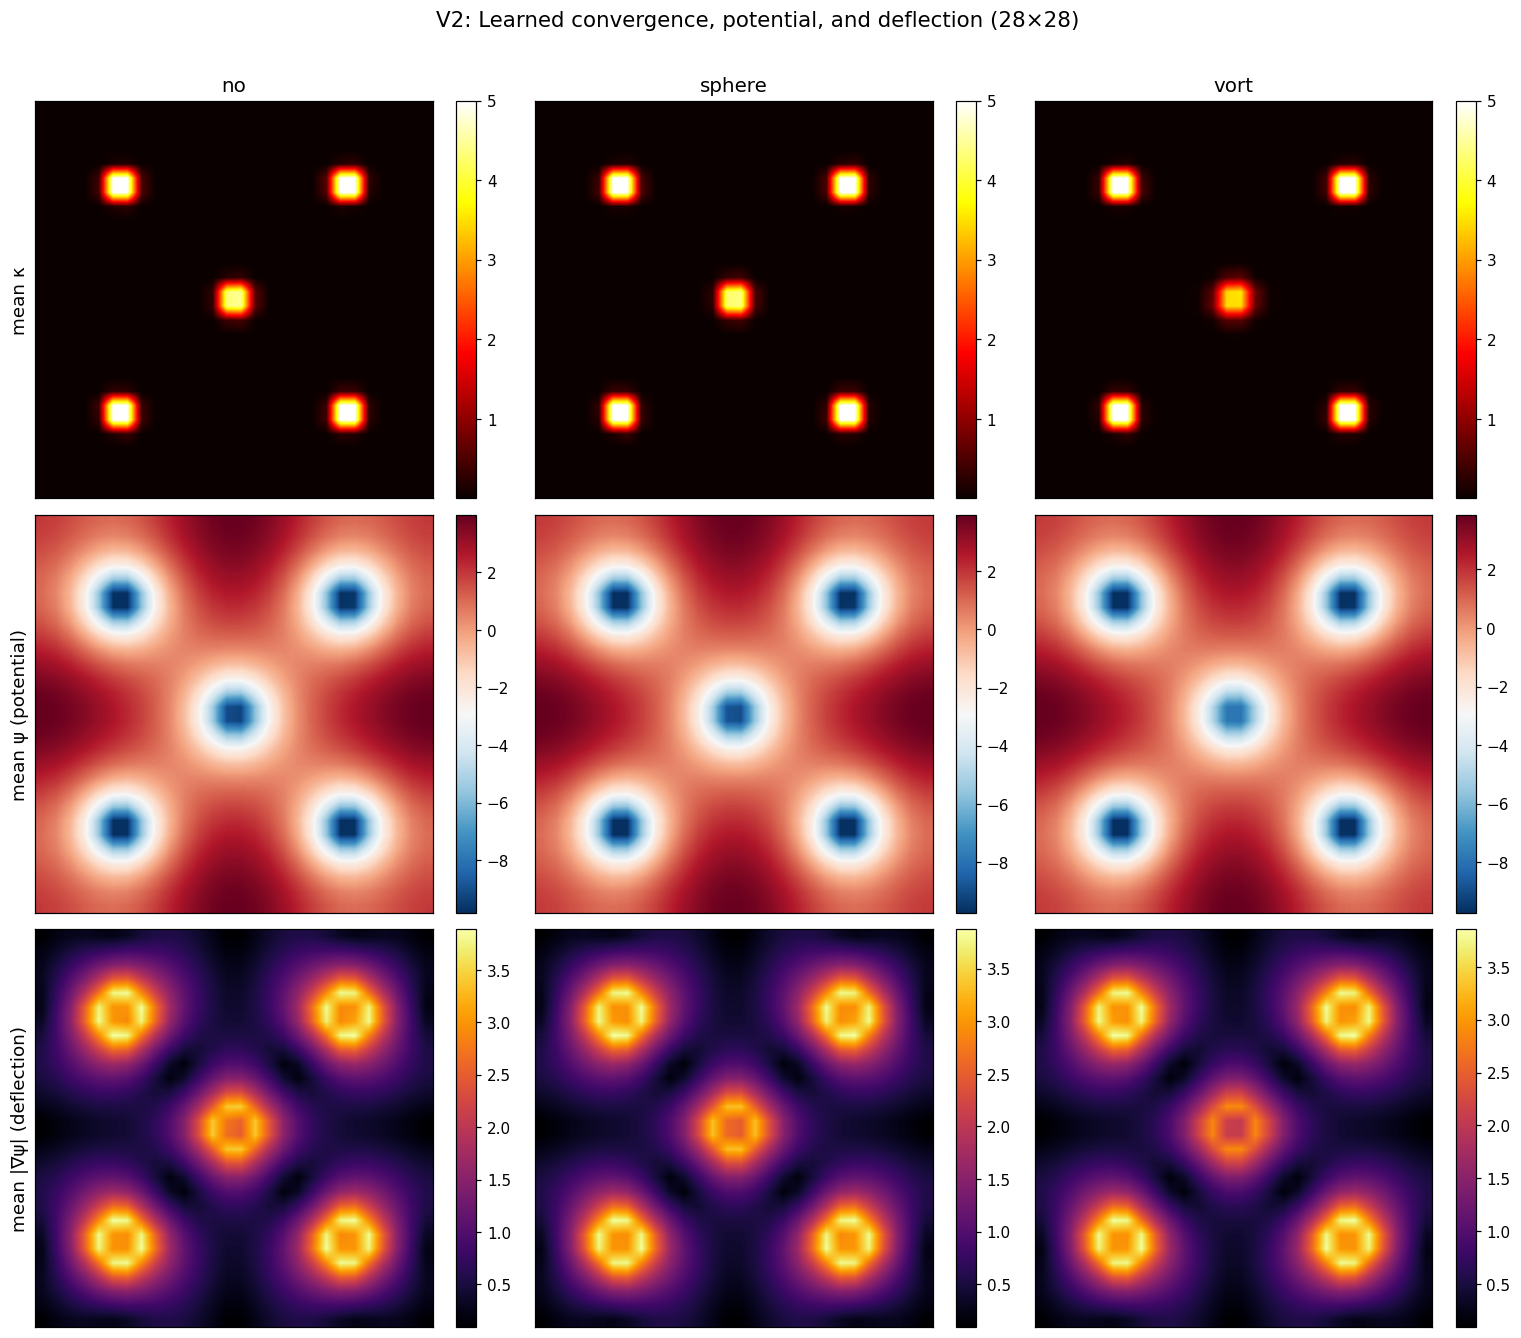

      no  mean(κ)=0.1417  std(κ)=0.7733  max(κ)=5.0000  spatial_var=0.597972
  sphere  mean(κ)=0.1397  std(κ)=0.7713  max(κ)=5.0000  spatial_var=0.594971
    vort  mean(κ)=0.1378  std(κ)=0.7542  max(κ)=5.0000  spatial_var=0.568850


In [43]:
model_v2.eval()
kv2_by_class = {c: [] for c in range(3)}
psi_by_class = {c: [] for c in range(3)}

with torch.no_grad():
    for imgs, labs in val_loader:
        logits, kappa, psi = model_v2(imgs.to(DEVICE))
        for k, ps, lab in zip(kappa.cpu(), psi.cpu(), labs):
            kv2_by_class[lab.item()].append(k.squeeze().numpy())
            psi_by_class[lab.item()].append(ps.squeeze().numpy())

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
row_labels = ['mean κ', 'mean ψ (potential)', 'mean |∇ψ| (deflection)']
for c in range(3):
    k_stack = np.stack(kv2_by_class[c])
    p_stack = np.stack(psi_by_class[c])
    mean_k = k_stack.mean(0)
    mean_p = p_stack.mean(0)
    grad_x = (np.roll(mean_p, -1, axis=1) - np.roll(mean_p, 1, axis=1)) / 2
    grad_y = (np.roll(mean_p, -1, axis=0) - np.roll(mean_p, 1, axis=0)) / 2
    defl   = np.sqrt(grad_x**2 + grad_y**2)

    for row, (data, cmap) in enumerate([(mean_k, 'hot'), (mean_p, 'RdBu_r'), (defl, 'inferno')]):
        im = axes[row, c].imshow(data, cmap=cmap, interpolation='bilinear')
        plt.colorbar(im, ax=axes[row, c], fraction=0.046)
        axes[row, c].set_xticks([]); axes[row, c].set_yticks([])
        if c == 0:
            axes[row, c].set_ylabel(row_labels[row], fontsize=12)
        if row == 0:
            axes[row, c].set_title(CLASS_NAMES[c], fontsize=13)

plt.suptitle('V2: Learned convergence, potential, and deflection (28×28)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(WEIGHTS_DIR + 'v2_kappa_psi_defl.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats
for c in range(3):
    k_stack = np.stack(kv2_by_class[c])
    print(f'{CLASS_NAMES[c]:>8s}  mean(κ)={k_stack.mean():.4f}  std(κ)={k_stack.std():.4f}  '
          f'max(κ)={k_stack.max():.4f}  spatial_var={k_stack.var(axis=(1,2)).mean():.6f}')

# Discussion
### Test I
EfficientNet-B0 achieves **96.2% val accuracy** and **0.9950 macro AUC** with
standard fine-tuning, establishing a strong non-physics-informed baseline.

### Test VII — V1 (Poisson via smoothing)
The initial physics-guided approach predicts κ at 7×7 resolution and enforces
∇²ψ = 2κ using a smoothing approximation for ψ. The per-class κ analysis
reveals the maps are **near-zero everywhere** (max κ ≈ 0.004), confirming that
the network found a trivial solution: κ → 0 satisfies the Poisson constraint
automatically and carries no discriminative information. The marginal AUC
improvement (0.9950 → 0.9953) comes entirely from the backbone, not the
physics branch.

### Test VII — V2 (Spectral Poisson + 28×28 κ)
V2 addresses V1's trivial-solution problem with three changes:
1. **Spectral Poisson solver**: ψ is computed via FFT, then the residual is
   evaluated with a discrete Laplacian stencil. The spectral-vs-discrete
   mismatch prevents the trivial zero solution.
2. **28×28 κ maps** with BatchNorm and GELU (vs 7×7 with ReLU).
3. **Gradient clipping** and **differential LR** (backbone 1e-5, heads 3e-4)
   to prevent the NaN explosion seen without stabilization.

### Connection to the full GSoC project
These experiments reveal a fundamental limitation of auxiliary κ-based losses:
predicting convergence from image features and enforcing Poisson is too
indirect — the network can satisfy the constraint without learning physically
meaningful mass distributions. The **LensPINN approach** solves this by
embedding the lensing equation *architecturally*: the encoder learns the
deflection field α(θ) and performs actual lensing inversion (image plane →
source plane). The model then classifies based on the *difference* between
the reconstructed source and the observed image — a much stronger physics
signal that cannot be trivially satisfied.

The transition from soft auxiliary losses (this test) to hard architectural
constraints (LensPINN) is the core insight motivating the proposed GSoC work.